In [138]:
print('h')

h


In [139]:
import pandas as pd

In [140]:
df = pd.read_csv('height-weight.csv')

In [141]:
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


In [142]:
df.shape

(23, 2)

In [143]:
df.columns

Index(['Weight', 'Height'], dtype='object')

In [144]:
df['Height']

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns


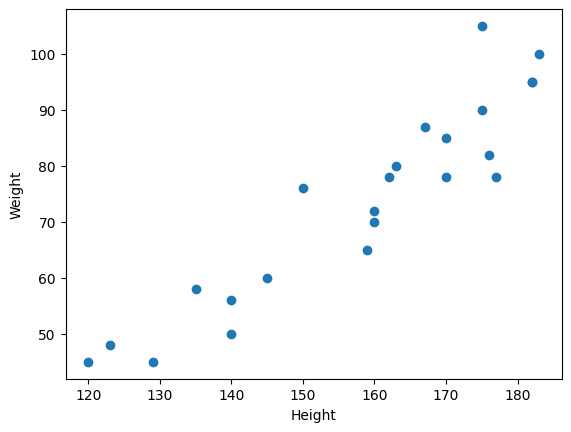

In [146]:
plt.xlabel("Height")
plt.ylabel("Weight")
plt.scatter(df['Height'],df['Weight'])

In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


In [148]:
df.isnull().sum()

Weight    0
Height    0
dtype: int64

In [149]:
X = df[['Height']]
y = df['Weight']

In [150]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=0)

In [151]:
X_test

,Height
11,182
10,176
21,140
14,170
20,129


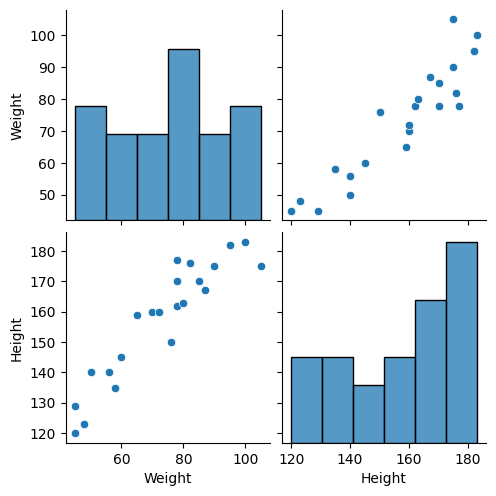

In [152]:
sns.pairplot(df)

In [153]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [154]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [155]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [156]:
y_pred = lr.predict(X_test)

In [157]:
lr.coef_

array([15.59386776])

In [158]:
lr.intercept_

np.float64(74.16666666666667)

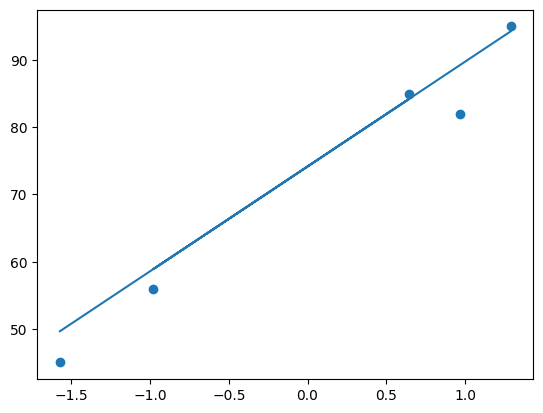

In [159]:
plt.plot(X_test,y_pred)
plt.scatter(X_test,y_test)

In [160]:
type(y_pred)

numpy.ndarray

In [161]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
print(mse,mae,rmse)

16.717198918100365 3.2650050425010817 4.088667132220519


In [162]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
r2

0.9530732121095319

In [163]:
adj_r2 = 1-((1-r2)*(len(X_test)-1)/(len(X_test)-X_test.shape[1]-1))
adj_r2

0.9374309494793759

In [164]:
X_test.shape

(5, 1)

In [165]:
import statsmodels.api as sm
ols = sm.OLS(X_train,y_train).fit()

In [166]:
prediction=ols.predict(X_test)
print(prediction)

[ 0.00347418  0.00260159 -0.00263391  0.00172901 -0.00423365]
